#Install Pcakage

In [20]:
!pip install gym tensorflow matplotlib numpy mat4py
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
from scipy.io import loadmat
from scipy.io import savemat
import os
os.chdir('/content/drive/My Drive')

In [22]:
import collections
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import gym
import tensorflow as tf
import os
import random
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.layers import RNN
import tensorflow.keras.backend as K
import sys
from gym import spaces
from gym.utils import seeding
import copy
from mat4py import loadmat
from tensorflow.keras import layers
from tensorflow import keras
import time
np.set_printoptions(precision=16)

from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
tf.keras.backend.set_floatx('float64')

# Environment Setup

In [23]:
# Transient Frequency Control Porblem Environment
class Transient_Frequency(gym.Env):
    def  __init__(self,M,Minv,F,D,R,Rinv,Tm,Tminv,Pl,delta_t,dim_state):
        self.param_gamma=1
        self.M=M
        self.Minv=Minv
        self.F=F
        self.D=D
        self.R=R
        self.Rinv=Rinv
        self.Tm=Tm
        self.Tminv=Tminv
        self.Pl=Pl
        self.delta_t=delta_t
        self.dim_state=dim_state
        self.viewer = None
        self.state=[]

        # self.state_transfer =  np.vstack(( np.hstack((np.identity((dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                  np.hstack((delta_t*np.identity((dim_state)), np.identity((dim_state))-delta_t*np.diag(D.reshape(dim_state,))@np.diag(Minv.reshape(dim_state,)), -delta_t*np.diag(Tminv.reshape(dim_state,))@np.diag(Rinv.reshape(dim_state,)), -delta_t*1*np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                            np.hstack((np.zeros((dim_state,dim_state)), delta_t*np.diag(Minv.reshape(dim_state,)), np.identity((dim_state))-delta_t*np.diag(Tminv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                                   np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), delta_t*np.diag(Tminv.reshape(dim_state,)), np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                                       np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity((dim_state)))) ))

        self.state_transfer =  np.vstack(( np.hstack((np.identity((dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
                                         np.hstack((delta_t*np.identity((dim_state)), np.identity((dim_state))-delta_t*np.diag(D.reshape(dim_state,))@np.diag(Minv.reshape(dim_state,)), -delta_t*np.diag(Tminv.reshape(dim_state,))@np.diag(Rinv.reshape(dim_state,)), -delta_t*3*np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
                                                   np.hstack((np.zeros((dim_state,dim_state)), delta_t*np.diag(Minv.reshape(dim_state,)), np.identity((dim_state))-delta_t*np.diag(Tminv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
                                                          np.hstack((np.zeros((dim_state,dim_state)), delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
                                                              np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity((dim_state)))) ))

        self.power_injection_mat = np.hstack((np.zeros((dim_state,dim_state)), -delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.input_mat = np.hstack((np.zeros((dim_state,dim_state)), -delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), delta_t*np.identity((dim_state))))

        self.diff_mat = np.hstack((np.zeros((dim_state,dim_state)), -delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        # self.gen_input_mat = np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), -delta_t*np.identity((dim_state)), np.zeros((dim_state,dim_state))))

        self.select_omega = np.vstack((np.zeros((dim_state,dim_state)), np.identity(dim_state), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.select_theta = np.vstack((np.identity(dim_state), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.select_Pm = np.vstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity(dim_state), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.select_Pg = np.vstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity(dim_state), np.zeros((dim_state,dim_state))))

        self.select_E = np.vstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)),np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity(dim_state)))


    def step(self,action,Pl_change):

        theta_difference_sum =np.sum(np.sin((np.transpose(self.state@self.select_theta)@np.ones((1,dim_state)) - np.ones((dim_state,1))@(self.state@self.select_theta)))*F,axis=1)

        self.state=copy.deepcopy(self.state@self.state_transfer + (Pl+Pl_change)@self.power_injection_mat + action@self.input_mat + theta_difference_sum@self.diff_mat)
        return self.state

    def set_state(self, state_input):
        self.state=state_input

In [24]:
# Simulation data load from IEEE 39-bus system

data = loadmat('/content/drive/MyDrive/Colab Notebooks/IEEE_39bus_Kron.mat')

K_EN=data['Kron_39bus']['K']
K_EN=np.asarray(K_EN, dtype=np.float64)

H=data['Kron_39bus']['H']
H=np.asarray(H, dtype=np.float64)

Damp=data['Kron_39bus']['D']
Damp=np.asarray(Damp, dtype=np.float64)

omega_R=data['Kron_39bus']['omega_R']

# A_EN=data['Kron_39bus']['A']
# A_EN=np.asarray(A_EN, dtype=np.float64)

# gamma=data['Kron_39bus']['gamma']
# gamma=np.asarray(gamma, dtype=np.float64)


# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-adjacency-matrix.mat')
# C=data['D']
# C=np.asarray(C, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-power-initial-balanced.mat')
# Power_initial=data['power_initial']
# Power_initial=np.asarray(Power_initial, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-rotational-inertial-generator.mat')
# Rotational_inertial_generator=data['rotational_inertial_generator']
# Rotational_inertial_generator=np.asarray(Rotational_inertial_generator, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-rotational-inertial-load.mat')
# Rotational_inertial_load=data['rotational_inertial_load']
# Rotational_inertial_load=np.asarray(Rotational_inertial_load, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-susceptance-matrix.mat')
# B=data['D_reactance']
# B=np.asarray(B, dtype=np.float64)

In [25]:
dim_state=10 #dimension of action space
dim_state_whole=5*dim_state #dimension of state space
action_units=dim_state
delta_t=0.01
M=H.reshape(dim_state)*2/omega_R*2*np.pi
# M[9] = .1*M[9]
Minv = 1/M
D=np.zeros(dim_state,dtype=np.float64)
D[0]=2*590/100
D[1:8]=2*865/100
D[8:10]=2*911/100
D=D/omega_R*2*np.pi
R=0.1*np.ones((1,dim_state),dtype=np.float64) #0.5
F=K_EN
Tm=7*np.ones((1,dim_state),dtype=np.float64) #7
# Tm[:,9] = 1
Rinv = 1/R
Tminv = 1/Tm
Power_initial=np.array([[0.19983394, 0.25653884, 0.25191885, 0.10242008, 0.34510365,
         -0.23206371,  -0.4404325 ,  -0.5896664 ,  -0.26257738, 0.36892462]],dtype=np.float32)
syn_frequency=-np.sum(Power_initial)/(np.sum(D) + np.sum(1/R))
Pl=copy.deepcopy(Power_initial)
Pl_nominal=copy.deepcopy(Pl)
Penalty_action= 0.2
Penalty_E= 2
equilibrium_init=np.array([[ -0.05420687, -0.07780334, -0.07351729, -0.05827823, -0.09359571,
        -0.02447385, -0.00783582,  0.00259523, -0.0162409 , -0.06477749,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.]],dtype=np.float64)
env = Transient_Frequency(M,Minv,F,D,R,Rinv,Tm,Tminv,Pl,delta_t,dim_state)

# RNN

In [26]:
# 集成控制器：结合RLB的安全稳定性保证和ESS的SOC保护
class MinimalRNNCell_Integrated(tf.keras.layers.Layer):

    def __init__(self, units, action_units, internal_units, env, batchsize, **kwargs):
        self.units = units
        self.state_size = units
        self.action_units = action_units
        self.internal_units = internal_units
        self.batchsize = batchsize

        # 使用环境中的常量
        self.state_transfer = tf.constant(env.state_transfer, dtype=tf.float64)
        self.power_injection_mat = tf.constant(env.power_injection_mat, dtype=tf.float64)
        self.input_mat = tf.constant(env.input_mat, dtype=tf.float64)
        self.diff_mat = tf.constant(env.diff_mat, dtype=tf.float64)
        self.select_omega = tf.constant(env.select_omega, dtype=tf.float64)
        self.select_theta = tf.constant(env.select_theta, dtype=tf.float64)
        self.select_E = tf.constant(env.select_E, dtype=tf.float64)
        self.Multiply_ones = tf.tile(tf.ones((action_units, action_units), dtype=tf.float64)[None], [batchsize, 1, 1])

        # 从环境中获取 F 和 Pl
        self.F = tf.constant(env.F, dtype=tf.float64)
        self.Pl = tf.constant(env.Pl, dtype=tf.float64)

        # RNN结构参数
        self.w_recover = tf.constant(tf.linalg.band_part(-tf.ones((internal_units, internal_units), dtype=tf.float64), 0, 1)
                                    + 2*tf.eye(internal_units, dtype=tf.float64), dtype=tf.float64)
        self.b_recover = tf.constant(tf.linalg.band_part(tf.ones((internal_units, internal_units), dtype=tf.float64), 0, -1)
                                    - tf.eye(internal_units, dtype=tf.float64), dtype=tf.float64)
        self.ones_frequency = tf.ones((action_units, internal_units), dtype=tf.float64)

        # 频率安全边界和ESS参数
        self.omega_max = 0.5  # 最大频率偏差 0.5 Hz
        self.omega_min = -0.5  # 最小频率偏差 -0.5 Hz
        self.E_upper = 0.3   # ESS容量上限
        self.E_lower = -0.3  # ESS容量下限
        self.Pe_upper = 1.0  # ESS最大充电功率
        self.Pe_lower = -1.0 # ESS最大放电功率

        super(MinimalRNNCell_Integrated, self).__init__(**kwargs)

    def build(self, input_shape):
        # ==================== RLB部分：稳定性保证参数 ====================
        # 频率安全屏障函数参数
        self.w_plus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer='uniform',
            trainable=True,
            name='w_plus_temp')

        self.b_plus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.02),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.02),
            name='b_plus_temp')

        self.w_minus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer='uniform',
            trainable=True,
            name='w_minus_temp')

        self.b_minus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.02),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.02),
            name='b_minus_temp')

        # 预算分配参数
        self.d_temp = self.add_weight(
            shape=(1, self.action_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.1, maxval=0.1),
            trainable=True,
            name='d_temp')

        # ==================== ESS部分：SOC安全参数 ====================
        self.thr_upper_temp = self.add_weight(
            shape=(self.action_units,),
            initializer=tf.keras.initializers.Constant(0.9),  # 初始值设为0.9
            trainable=True,
            name='thr_upper_temp')

        self.thr_lower_temp = self.add_weight(
            shape=(self.action_units,),
            initializer=tf.keras.initializers.Constant(0.1),  # 初始值设为0.1
            trainable=True,
            name='thr_lower_temp')

        # ==================== 控制策略参数 ====================
        self.q_plus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer='uniform',
            trainable=True,
            name='q_plus_temp')

        self.c_plus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.1, maxval=0.1),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.2),
            name='c_plus_temp')

        self.q_minus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer='uniform',
            trainable=True,
            name='q_minus_temp')

        self.c_minus_temp0 = self.add_weight(
            shape=(self.action_units, self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.1, maxval=0.1),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.2),
            name='c_minus_temp')

        self.built = True

    def call(self, inputs, states):
        prev_output = states[0]
        states_controlled = K.dot(prev_output, self.select_omega)
        states_E = K.dot(prev_output, self.select_E)

        # ==================== RLB部分：频率安全屏障函数 ====================
        w_plus_temp = tf.math.abs(self.w_plus_temp0)
        b_plus_temp = tf.math.abs(self.b_plus_temp0)
        w_minus_temp = tf.math.abs(self.w_minus_temp0)
        b_minus_temp = tf.math.abs(self.b_minus_temp0)

        w_plus = K.dot(w_plus_temp, self.w_recover)
        b_plus = K.dot(-b_plus_temp, self.b_recover)
        w_minus = K.dot(-w_minus_temp, self.w_recover)
        b_minus = K.dot(-b_minus_temp, self.b_recover)

        # 计算频率安全屏障函数
        alpha_plus = K.sum(K.relu(-K.dot(tf.linalg.diag(states_controlled - self.omega_max), self.ones_frequency) + b_plus) * w_plus, axis=2)
        alpha_minus = K.sum(K.relu(-K.dot(tf.linalg.diag(self.omega_min - states_controlled), self.ones_frequency) + b_minus) * w_minus, axis=2)

        # ==================== 简化的预算分配机制 ====================
        d = self.d_temp
        budgets = tf.squeeze(d)

        # ==================== 控制策略计算 ====================
        q_plus = self.q_plus_temp0
        c_plus = -tf.math.abs(self.c_plus_temp0)
        q_minus = self.q_minus_temp0
        c_minus = -tf.math.abs(self.c_minus_temp0)

        # 计算基础控制动作
        control_plus = K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled), self.ones_frequency) + c_plus) * q_plus, axis=2)
        control_minus = K.sum(K.relu(-K.dot(tf.linalg.diag(states_controlled), self.ones_frequency) + c_minus) * q_minus, axis=2)

        base_action = control_plus + control_minus

        # ==================== 频率安全约束应用 ====================
        frequency_safe_action = base_action

        # 当频率接近边界时应用屏障约束
        upper_freq_violation = tf.maximum(states_controlled - 0.8 * self.omega_max, 0)
        lower_freq_violation = tf.maximum(0.8 * self.omega_min - states_controlled, 0)

        frequency_safe_action = tf.where(
            upper_freq_violation > 0,
            tf.minimum(frequency_safe_action, -alpha_plus / (upper_freq_violation + 1e-8) + budgets),
            frequency_safe_action
        )

        frequency_safe_action = tf.where(
            lower_freq_violation > 0,
            tf.maximum(frequency_safe_action, alpha_minus / (lower_freq_violation + 1e-8) + budgets),
            frequency_safe_action
        )

        # ==================== ESS部分：SOC安全滤波 ====================
        thr_lower = K.sigmoid(self.thr_lower_temp)
        thr_upper = K.sigmoid(self.thr_upper_temp)

        boundary_upper = thr_upper * self.E_upper
        boundary_lower = thr_lower * self.E_lower

        upper_barrier = (self.E_upper - states_E) / (self.E_upper - boundary_upper + 1e-8)
        lower_barrier = (states_E - self.E_lower) / (boundary_lower - self.E_lower + 1e-8)

        def get_inside_bound(E, lower, upper):
            return tf.cast(tf.logical_and(E >= lower, E <= upper), tf.float64)

        def get_beyond_bound(E, upper):
            return tf.cast(E > upper, tf.float64)

        def get_below_bound(E, lower):
            return tf.cast(E < lower, tf.float64)

        # 应用SOC安全滤波
        final_action = (
            get_inside_bound(states_E, boundary_lower, boundary_upper) * frequency_safe_action +
            get_beyond_bound(states_E, boundary_upper) * tf.minimum(frequency_safe_action, upper_barrier * frequency_safe_action) +
            get_below_bound(states_E, boundary_lower) * tf.maximum(frequency_safe_action, lower_barrier * frequency_safe_action)
        )

        # 最终动作限幅
        action = tf.math.minimum(tf.math.maximum(final_action, self.Pe_lower), self.Pe_upper)

        # ==================== 系统状态更新 ====================
        theta_difference_sum = K.sum(
            tf.math.sin(
                tf.matmul(tf.linalg.diag(K.dot(prev_output, self.select_theta)), self.Multiply_ones) -
                tf.matmul(self.Multiply_ones, tf.linalg.diag(K.dot(prev_output, self.select_theta)))
            ) * self.F, axis=2
        )

        new_state = (prev_output @ self.state_transfer +
                    (self.Pl + inputs) @ self.power_injection_mat +
                    action @ self.input_mat +
                    theta_difference_sum @ self.diff_mat)

        frequency = K.dot(new_state, self.select_omega)
        E = K.dot(new_state, self.select_E)

        return [frequency, action, E, base_action], [new_state]

In [27]:
start = time.time()

episodes = 100
units = dim_state_whole  # 50
action_units = dim_state  # 10
internal_units = 50
T = 500
Batch_num = 600

# 定义缺失变量
theta_rnn_init_bound = 0.1
omega_rnn_init_bound = 0.01
Pm_rnn_init_bound = 0.1
Pg_rnn_init_bound = 0.1
E_rnn_init_bound = 0.1

# 惩罚系数
Penalty_action = 0.2
Penalty_E = 2
Penalty_freq_safety = 1.0  # 新增频率安全惩罚系数

# 创建集成控制器模型
cell = MinimalRNNCell_Integrated(units, action_units, internal_units, env, Batch_num)
layer = tf.keras.layers.RNN(cell, return_sequences=True, stateful=True)

input_1 = tf.keras.Input(batch_shape=(Batch_num, T, action_units))
outputs = layer(input_1)
model = tf.keras.models.Model(inputs=input_1, outputs=outputs)
model.compile(optimizer='Adam', loss='mse', metrics=['accuracy'])

# 测试前向传播
try:
    x0 = np.ones((Batch_num, T, action_units), dtype=np.float32)
    y0 = model(x0)
    print("Integrated model forward pass successful!")
except Exception as e:
    print(f"Error in forward pass: {e}")

Loss_record = []
global_step = tf.Variable(0, trainable=False)
learning_rate_initial = 0.05  # 降低学习率提高稳定性
decayed_lr = tf.keras.optimizers.schedules.ExponentialDecay(
    learning_rate_initial, 25, 0.8, staircase=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=decayed_lr)

PrintUpdate = 5  # 每5个episode打印一次
num_gen_step = 10
Percent_step_change = 1
range_step_change = 1

for i in range(episodes):
    # 生成初始状态
    initial_state1 = np.random.uniform(-theta_rnn_init_bound, theta_rnn_init_bound, (Batch_num, dim_state))
    initial_state2 = np.random.uniform(-omega_rnn_init_bound, omega_rnn_init_bound, (Batch_num, dim_state))
    initial_state3 = np.random.uniform(-Pm_rnn_init_bound, Pm_rnn_init_bound, (Batch_num, dim_state))
    initial_state4 = np.random.uniform(-Pg_rnn_init_bound, Pg_rnn_init_bound, (Batch_num, dim_state))
    initial_state5 = np.random.uniform(-E_rnn_init_bound, E_rnn_init_bound, (Batch_num, dim_state))
    initial_state = np.hstack((initial_state1, initial_state2, initial_state3, initial_state4, initial_state5)) + equilibrium_init

    # 生成负载变化
    Pl_change = np.zeros((Batch_num, T, action_units), dtype=np.float32)
    for gen_interupt in range(num_gen_step):
        idx_gen_deviation = np.random.randint(0, action_units, Batch_num * Percent_step_change)
        idx_batch_deviation = np.random.randint(0, Batch_num, Batch_num * Percent_step_change)
        step_change = np.random.uniform(-1, 1, (Batch_num * Percent_step_change)) * range_step_change
        for t_interupt in range(T):
            Pl_change[idx_batch_deviation, t_interupt, idx_gen_deviation] = step_change

    # 重置状态
    layer.reset_states()

    with tf.GradientTape() as tape:
        Pl_change_tensor = tf.convert_to_tensor(Pl_change, dtype=tf.float32)
        outputs = model(Pl_change_tensor, training=True)
        frequency, action, E, nonlinear = outputs

        # 集成损失函数：同时考虑频率性能和SOC安全
        loss = (Penalty_action * tf.reduce_sum(tf.square(action)) / (Batch_num * T) +
                tf.reduce_sum(tf.reduce_max(tf.abs(frequency), axis=1)) / Batch_num +
                Penalty_E * tf.reduce_sum(tf.square(E[:, -1, :])) / Batch_num +
                # 频率安全惩罚项
                Penalty_freq_safety * tf.reduce_sum(
                    tf.maximum(frequency - cell.omega_max, 0) +
                    tf.maximum(cell.omega_min - frequency, 0)
                ) / (Batch_num * T) +
                # 动作平滑性惩罚
                0.1 * tf.reduce_sum(tf.square(action[:, 1:, :] - action[:, :-1, :])) / (Batch_num * (T-1)))

    grads = tape.gradient(loss, model.trainable_variables)
    if grads is not None:
        # 梯度裁剪
        grads = [tf.clip_by_value(grad, -1.0, 1.0) for grad in grads]
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    Loss_record.append(loss.numpy())

    if i % PrintUpdate == 0:
        # 计算监控指标
        max_freq_dev = tf.reduce_max(tf.abs(frequency)).numpy()
        freq_violations = tf.reduce_sum(
            tf.maximum(frequency - cell.omega_max, 0) +
            tf.maximum(cell.omega_min - frequency, 0)
        ).numpy() / (Batch_num * T)

        soc_violations = tf.reduce_sum(
            tf.maximum(E - cell.E_upper, 0) +
            tf.maximum(cell.E_lower - E, 0)
        ).numpy() / (Batch_num * T)

        print(f'Episode {i}:')
        print(f'  Total Loss: {loss.numpy():.6f}')
        print(f'  Frequency Loss: {tf.reduce_sum(tf.reduce_max(tf.abs(frequency), axis=1)).numpy() / Batch_num:.6f}')
        print(f'  Action Loss: {Penalty_action * tf.reduce_sum(tf.square(action)).numpy() / (Batch_num * T):.6f}')
        print(f'  SOC Loss: {Penalty_E * tf.reduce_sum(tf.square(E[:, -1, :])).numpy() / Batch_num:.6f}')
        print(f'  Max Frequency Deviation: {max_freq_dev:.4f}')
        print(f'  Frequency Violations: {freq_violations:.6f}')
        print(f'  SOC Violations: {soc_violations:.6f}')
        print()

end = time.time()
print(f"Integrated training completed in {end - start:.2f} seconds")

# 保存训练好的控制器参数
print("Saving trained controller parameters...")
w_plus_temp = tf.math.abs(model.variables[0])
b_plus_temp = tf.math.abs(model.variables[1])
w_minus_temp = tf.math.abs(model.variables[2])
b_minus_temp = tf.math.abs(model.variables[3])
d_temp = model.variables[4]
thr_upper_temp = model.variables[5]
thr_lower_temp = model.variables[6]
q_plus_temp0 = model.variables[7]
c_plus_temp0 = model.variables[8]
q_minus_temp0 = model.variables[9]
c_minus_temp0 = model.variables[10]

# 恢复参数结构
w_plus = (K.dot(w_plus_temp, cell.w_recover)).numpy()
b_plus = (K.dot(-b_plus_temp, cell.b_recover)).numpy()
w_minus = (K.dot(-w_minus_temp, cell.w_recover)).numpy()
b_minus = (K.dot(-b_minus_temp, cell.b_recover)).numpy()
thr_upper = (K.sigmoid(thr_upper_temp)).numpy()
thr_lower = (K.sigmoid(thr_lower_temp)).numpy()
d = d_temp.numpy()
q_plus = q_plus_temp0.numpy()
c_plus = c_plus_temp0.numpy()
q_minus = q_minus_temp0.numpy()
c_minus = c_minus_temp0.numpy()

file_name = 'optimal_controllers_integrated.mat'
savemat(file_name, {
    'w_plus': w_plus, 'b_plus': b_plus,
    'w_minus': w_minus, 'b_minus': b_minus,
    'thr_upper': thr_upper, 'thr_lower': thr_lower,
    'd': d, 'q_plus': q_plus, 'c_plus': c_plus,
    'q_minus': q_minus, 'c_minus': c_minus,
    'Loss_record': np.array(Loss_record)
})

print("Controller parameters saved successfully!")

Integrated model forward pass successful!
Episode 0:
  Total Loss: 1.420713
  Frequency Loss: 1.401218
  Action Loss: 0.000301
  SOC Loss: 0.019169
  Max Frequency Deviation: 0.4794
  Frequency Violations: 0.000000
  SOC Violations: 0.000000

Episode 5:
  Total Loss: 0.958920
  Frequency Loss: 0.731215
  Action Loss: 0.011684
  SOC Loss: 0.216005
  Max Frequency Deviation: 0.2615
  Frequency Violations: 0.000000
  SOC Violations: 0.000000

Episode 10:
  Total Loss: 0.954545
  Frequency Loss: 0.695956
  Action Loss: 0.014897
  SOC Loss: 0.243666
  Max Frequency Deviation: 0.2772
  Frequency Violations: 0.000000
  SOC Violations: 0.000000

Episode 15:
  Total Loss: 0.937240
  Frequency Loss: 0.681879
  Action Loss: 0.015004
  SOC Loss: 0.240327
  Max Frequency Deviation: 0.2883
  Frequency Violations: 0.000000
  SOC Violations: 0.000000

Episode 20:
  Total Loss: 0.918311
  Frequency Loss: 0.673310
  Action Loss: 0.015231
  SOC Loss: 0.229738
  Max Frequency Deviation: 0.3034
  Frequency

# Simulation

In [31]:
print(controller_params.keys())

dict_keys(['w_plus', 'b_plus', 'w_minus', 'b_minus', 'thr_upper', 'thr_lower', 'd', 'q_plus', 'c_plus', 'q_minus', 'c_minus', 'Loss_record'])


In [44]:
# 加载训练好的集成控制器参数
controller_params = loadmat('optimal_controllers_integrated.mat')
w_plus = controller_params['w_plus']
b_plus = controller_params['b_plus']
w_minus = controller_params['w_minus']
b_minus = controller_params['b_minus']
thr_upper = controller_params['thr_upper']
thr_lower = controller_params['thr_lower']
d = controller_params['d']
q_plus = controller_params['q_plus']
c_plus = controller_params['c_plus']
q_minus = controller_params['q_minus']
c_minus = controller_params['c_minus']

def Action_Integrated(state, env):
    """集成控制器的动作计算函数 - 使用纯 numpy 实现"""
    # 首先确保所有参数都是 NumPy 数组
    thr_upper_arr = np.array(thr_upper, dtype=np.float64)
    thr_lower_arr = np.array(thr_lower, dtype=np.float64)
    w_plus_arr = np.array(w_plus, dtype=np.float64)
    b_plus_arr = np.array(b_plus, dtype=np.float64)
    w_minus_arr = np.array(w_minus, dtype=np.float64)
    b_minus_arr = np.array(b_minus, dtype=np.float64)
    d_arr = np.array(d, dtype=np.float64)
    q_plus_arr = np.array(q_plus, dtype=np.float64)
    c_plus_arr = np.array(c_plus, dtype=np.float64)
    q_minus_arr = np.array(q_minus, dtype=np.float64)
    c_minus_arr = np.array(c_minus, dtype=np.float64)

    states_controlled = state @ env.select_omega  # 形状: (1, 10)
    states_E = state @ env.select_E  # 形状: (1, 10)

    # ESS参数
    E_upper = 0.3
    E_lower = -0.3
    Pe_upper = 1.0
    Pe_lower = -1.0
    omega_max = 0.5
    omega_min = -0.5

    # RNN结构参数 - 使用 NumPy 替代 TensorFlow 的 band_part
    internal_units = 50

    # 创建 w_recover 的替代方案
    w_recover = -np.tril(np.ones((internal_units, internal_units))) + 2 * np.eye(internal_units)

    # 创建 b_recover 的替代方案
    b_recover = np.tril(np.ones((internal_units, internal_units)), -1)

    ones_frequency = np.ones((dim_state, internal_units))

    # ==================== RLB频率安全部分 ====================
    # 计算 alpha_plus 和 alpha_minus
    alpha_plus_input = -np.dot(np.diag(states_controlled[0] - omega_max), ones_frequency) + b_plus_arr
    alpha_plus = np.sum(np.maximum(alpha_plus_input, 0) * w_plus_arr, axis=1, keepdims=True)

    alpha_minus_input = -np.dot(np.diag(omega_min - states_controlled[0]), ones_frequency) + b_minus_arr
    alpha_minus = np.sum(np.maximum(alpha_minus_input, 0) * w_minus_arr, axis=1, keepdims=True)

    # 确保 alpha_plus 和 alpha_minus 的形状与 states_controlled 匹配
    alpha_plus = np.squeeze(alpha_plus, axis=-1)  # 形状: (1, 10)
    alpha_minus = np.squeeze(alpha_minus, axis=-1)  # 形状: (1, 10)

    # ==================== 控制策略计算 ====================
    # 计算基础控制动作
    control_plus_input = np.dot(np.diag(states_controlled[0]), ones_frequency) + c_plus_arr
    control_plus = np.sum(np.maximum(control_plus_input, 0) * q_plus_arr, axis=1, keepdims=True)

    control_minus_input = -np.dot(np.diag(states_controlled[0]), ones_frequency) + c_minus_arr
    control_minus = np.sum(np.maximum(control_minus_input, 0) * q_minus_arr, axis=1, keepdims=True)

    base_action = np.squeeze(control_plus + control_minus, axis=-1)  # 形状: (1, 10)

    # ==================== 频率安全约束 ====================
    budgets = np.squeeze(d_arr)  # 形状: (10,)
    frequency_safe_action = base_action

    # 频率安全屏障
    upper_freq_violation = np.maximum(states_controlled - 0.8 * omega_max, 0)
    lower_freq_violation = np.maximum(0.8 * omega_min - states_controlled, 0)

    # 使用逐元素操作避免形状不匹配
    for i in range(dim_state):
        if upper_freq_violation[0, i] > 0:
            frequency_safe_action[0, i] = min(
                frequency_safe_action[0, i],
                -alpha_plus[0, i] / (upper_freq_violation[0, i] + 1e-8) + budgets[i]
            )
        if lower_freq_violation[0, i] > 0:
            frequency_safe_action[0, i] = max(
                frequency_safe_action[0, i],
                alpha_minus[0, i] / (lower_freq_violation[0, i] + 1e-8) + budgets[i]
            )

    # ==================== ESS SOC安全滤波 ====================
    # 修复：确保 thr_upper 和 thr_lower 是适当形状的数组
    if thr_upper_arr.ndim == 1:
        thr_upper_reshaped = thr_upper_arr.reshape(1, -1)
    else:
        thr_upper_reshaped = thr_upper_arr

    if thr_lower_arr.ndim == 1:
        thr_lower_reshaped = thr_lower_arr.reshape(1, -1)
    else:
        thr_lower_reshaped = thr_lower_arr

    boundary_upper = thr_upper_reshaped * E_upper
    boundary_lower = thr_lower_reshaped * E_lower

    upper_barrier = (E_upper - states_E) / (E_upper - boundary_upper + 1e-8)
    lower_barrier = (states_E - E_lower) / (boundary_lower - E_lower + 1e-8)

    def get_inside_bound(E, lower, upper):
        return np.logical_and(E >= lower, E <= upper).astype(np.float64)

    def get_beyond_bound(E, upper):
        return (E > upper).astype(np.float64)

    def get_below_bound(E, lower):
        return (E < lower).astype(np.float64)

    # 应用SOC安全滤波
    final_action = (
        get_inside_bound(states_E, boundary_lower, boundary_upper) * frequency_safe_action +
        get_beyond_bound(states_E, boundary_upper) * np.minimum(frequency_safe_action, upper_barrier * frequency_safe_action) +
        get_below_bound(states_E, boundary_lower) * np.maximum(frequency_safe_action, lower_barrier * frequency_safe_action)
    )

    action = np.minimum(np.maximum(final_action, Pe_lower), Pe_upper)

    # 返回额外信息用于可视化
    safety_info = {
        'base_action': base_action,
        'frequency_safe_action': frequency_safe_action,
        'final_action': final_action,
        'upper_barrier': upper_barrier,
        'lower_barrier': lower_barrier,
        'states_E': states_E,
        'states_controlled': states_controlled,
        'boundary_upper': boundary_upper,
        'boundary_lower': boundary_lower
    }

    return base_action, action, safety_info

Starting integrated controller simulation...
Simulation progress: 0/2000
Simulation progress: 100/2000
Simulation progress: 200/2000
Simulation progress: 300/2000
Simulation progress: 400/2000
Simulation progress: 500/2000
Simulation progress: 600/2000
Simulation progress: 700/2000
Simulation progress: 800/2000
Simulation progress: 900/2000
Simulation progress: 1000/2000
Simulation progress: 1100/2000
Simulation progress: 1200/2000
Simulation progress: 1300/2000
Simulation progress: 1400/2000
Simulation progress: 1500/2000
Simulation progress: 1600/2000
Simulation progress: 1700/2000
Simulation progress: 1800/2000
Simulation progress: 1900/2000


/tmp/ipython-input-3730768166.py:395: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


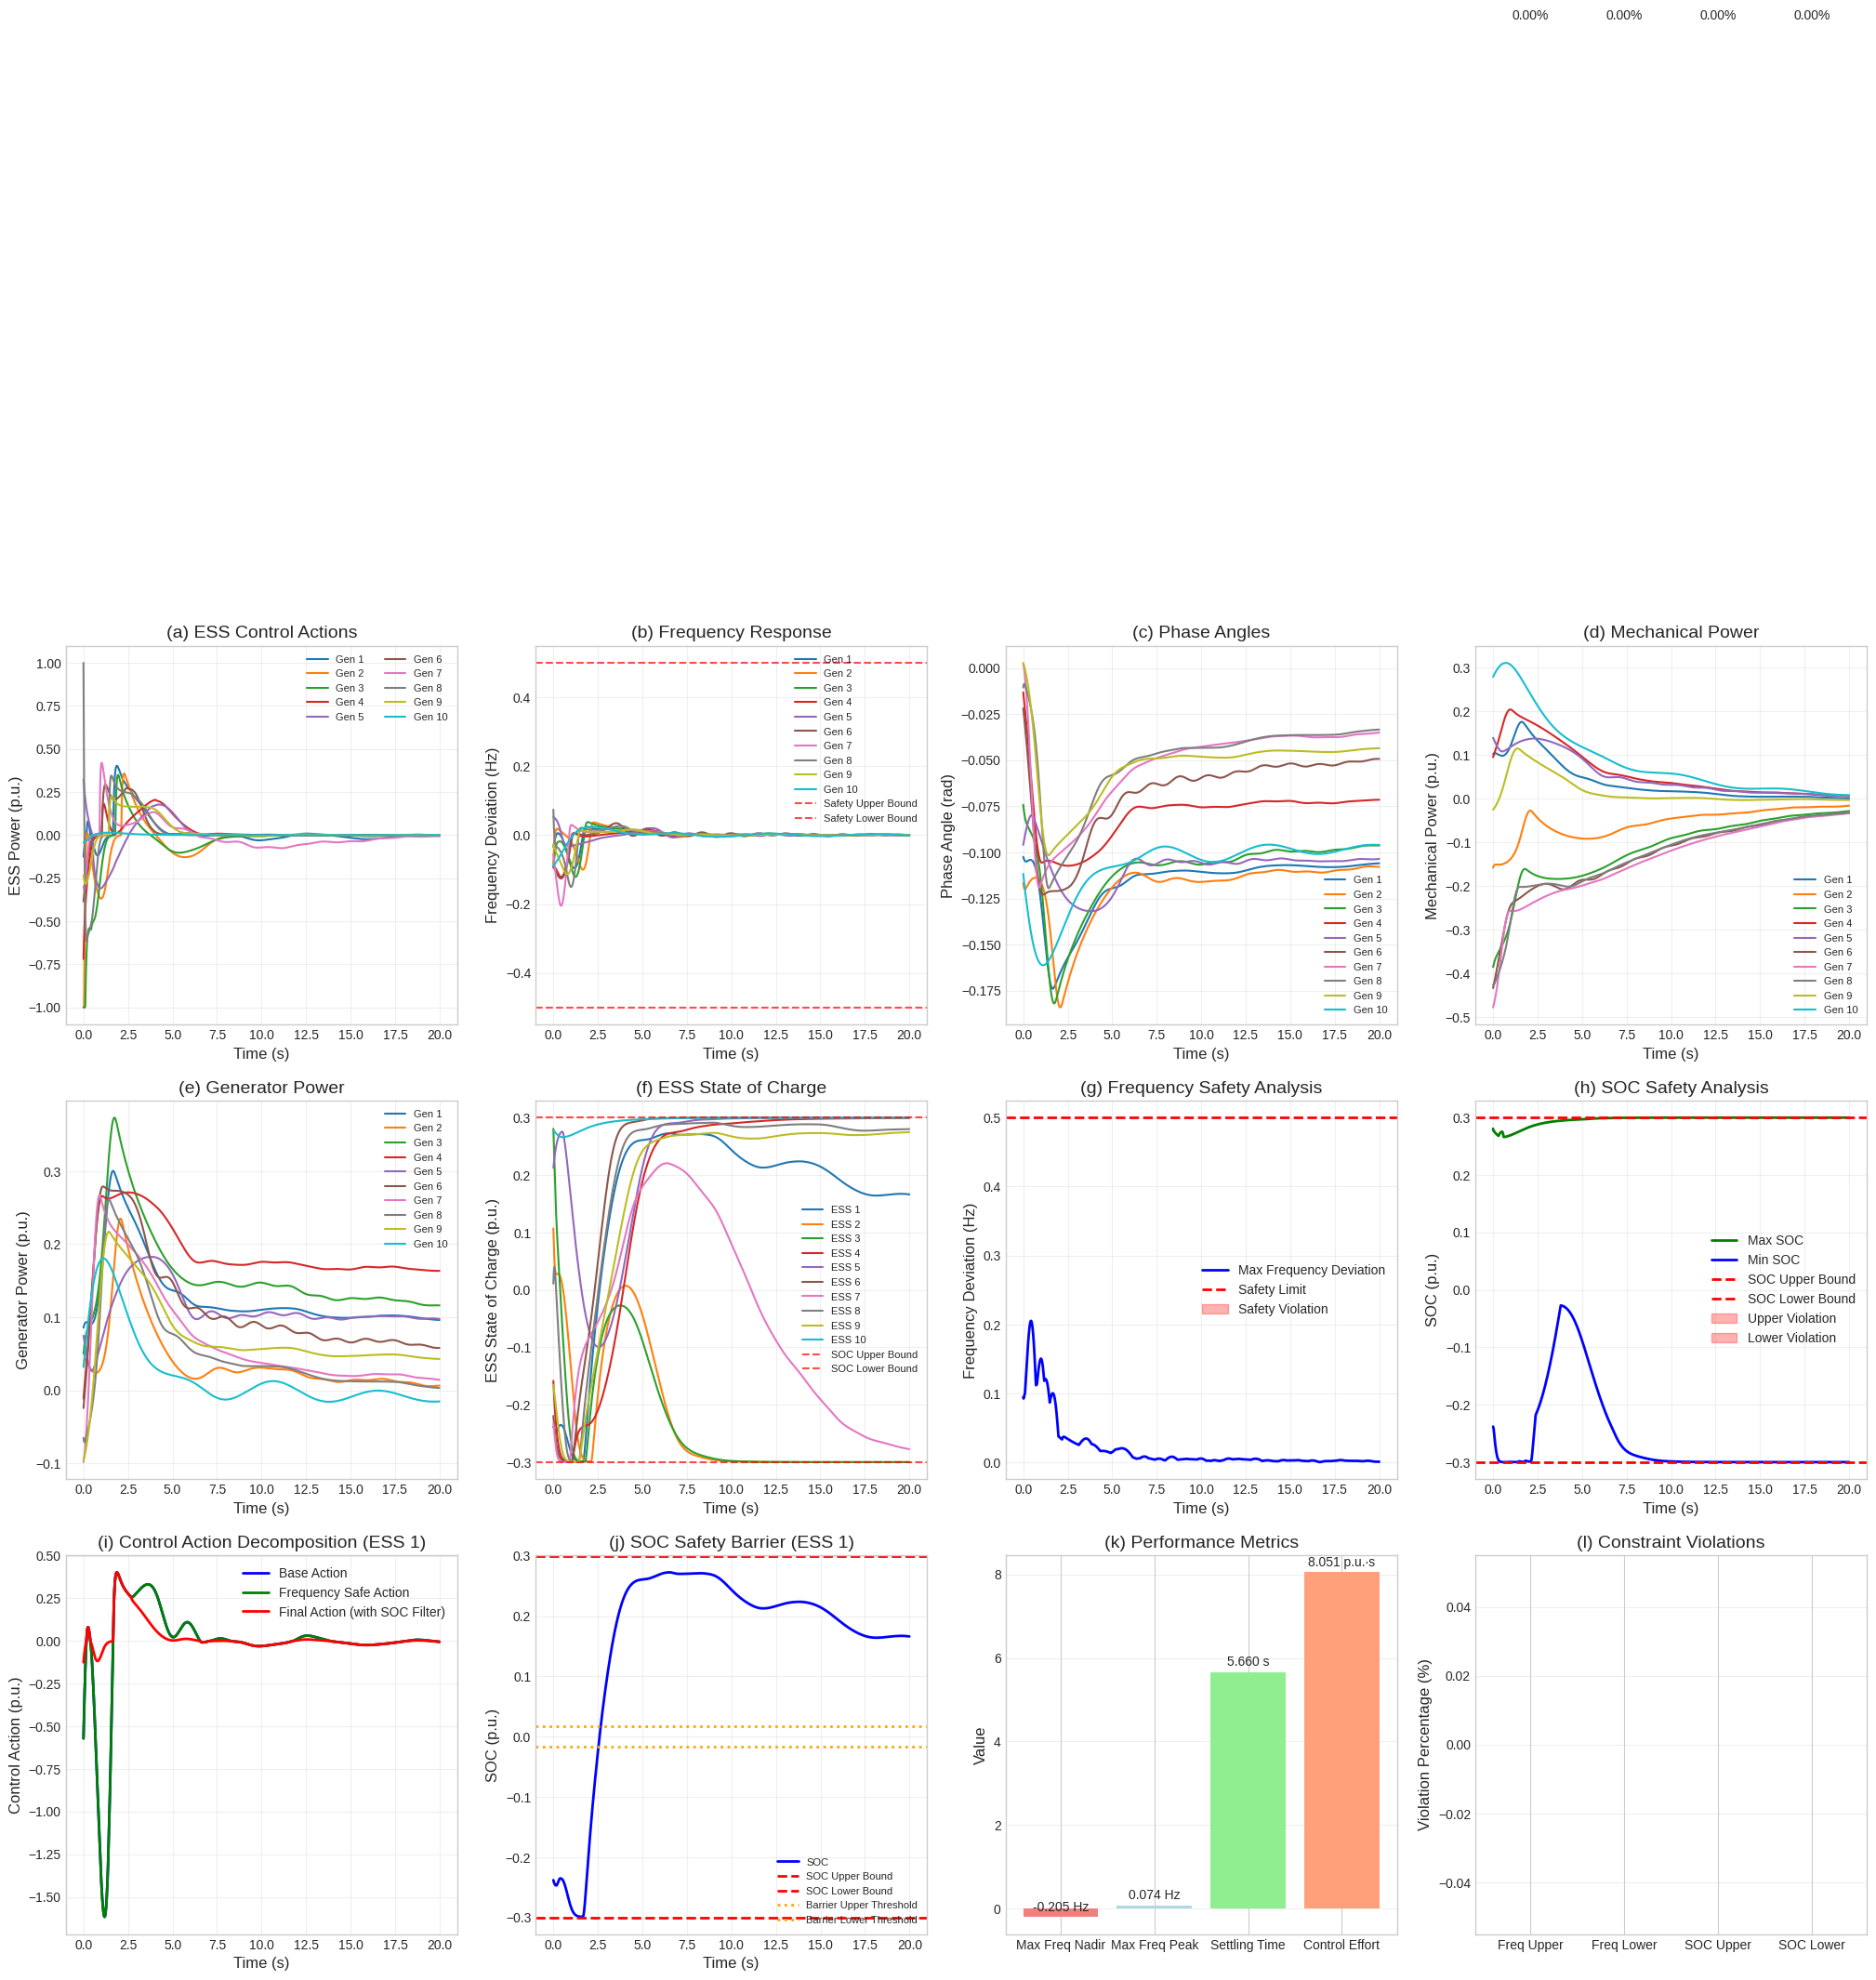


INTEGRATED CONTROLLER PERFORMANCE SUMMARY
Maximum Frequency Nadir: -0.2052 Hz
Maximum Frequency Peak: 0.0741 Hz
Settling Time (to ±0.02 Hz): 5.66 s
Total Control Effort: 8.0507 p.u.·s
Frequency Constraint Violations: 0.00%
SOC Constraint Violations: 0.00%

Visualizing control policy...


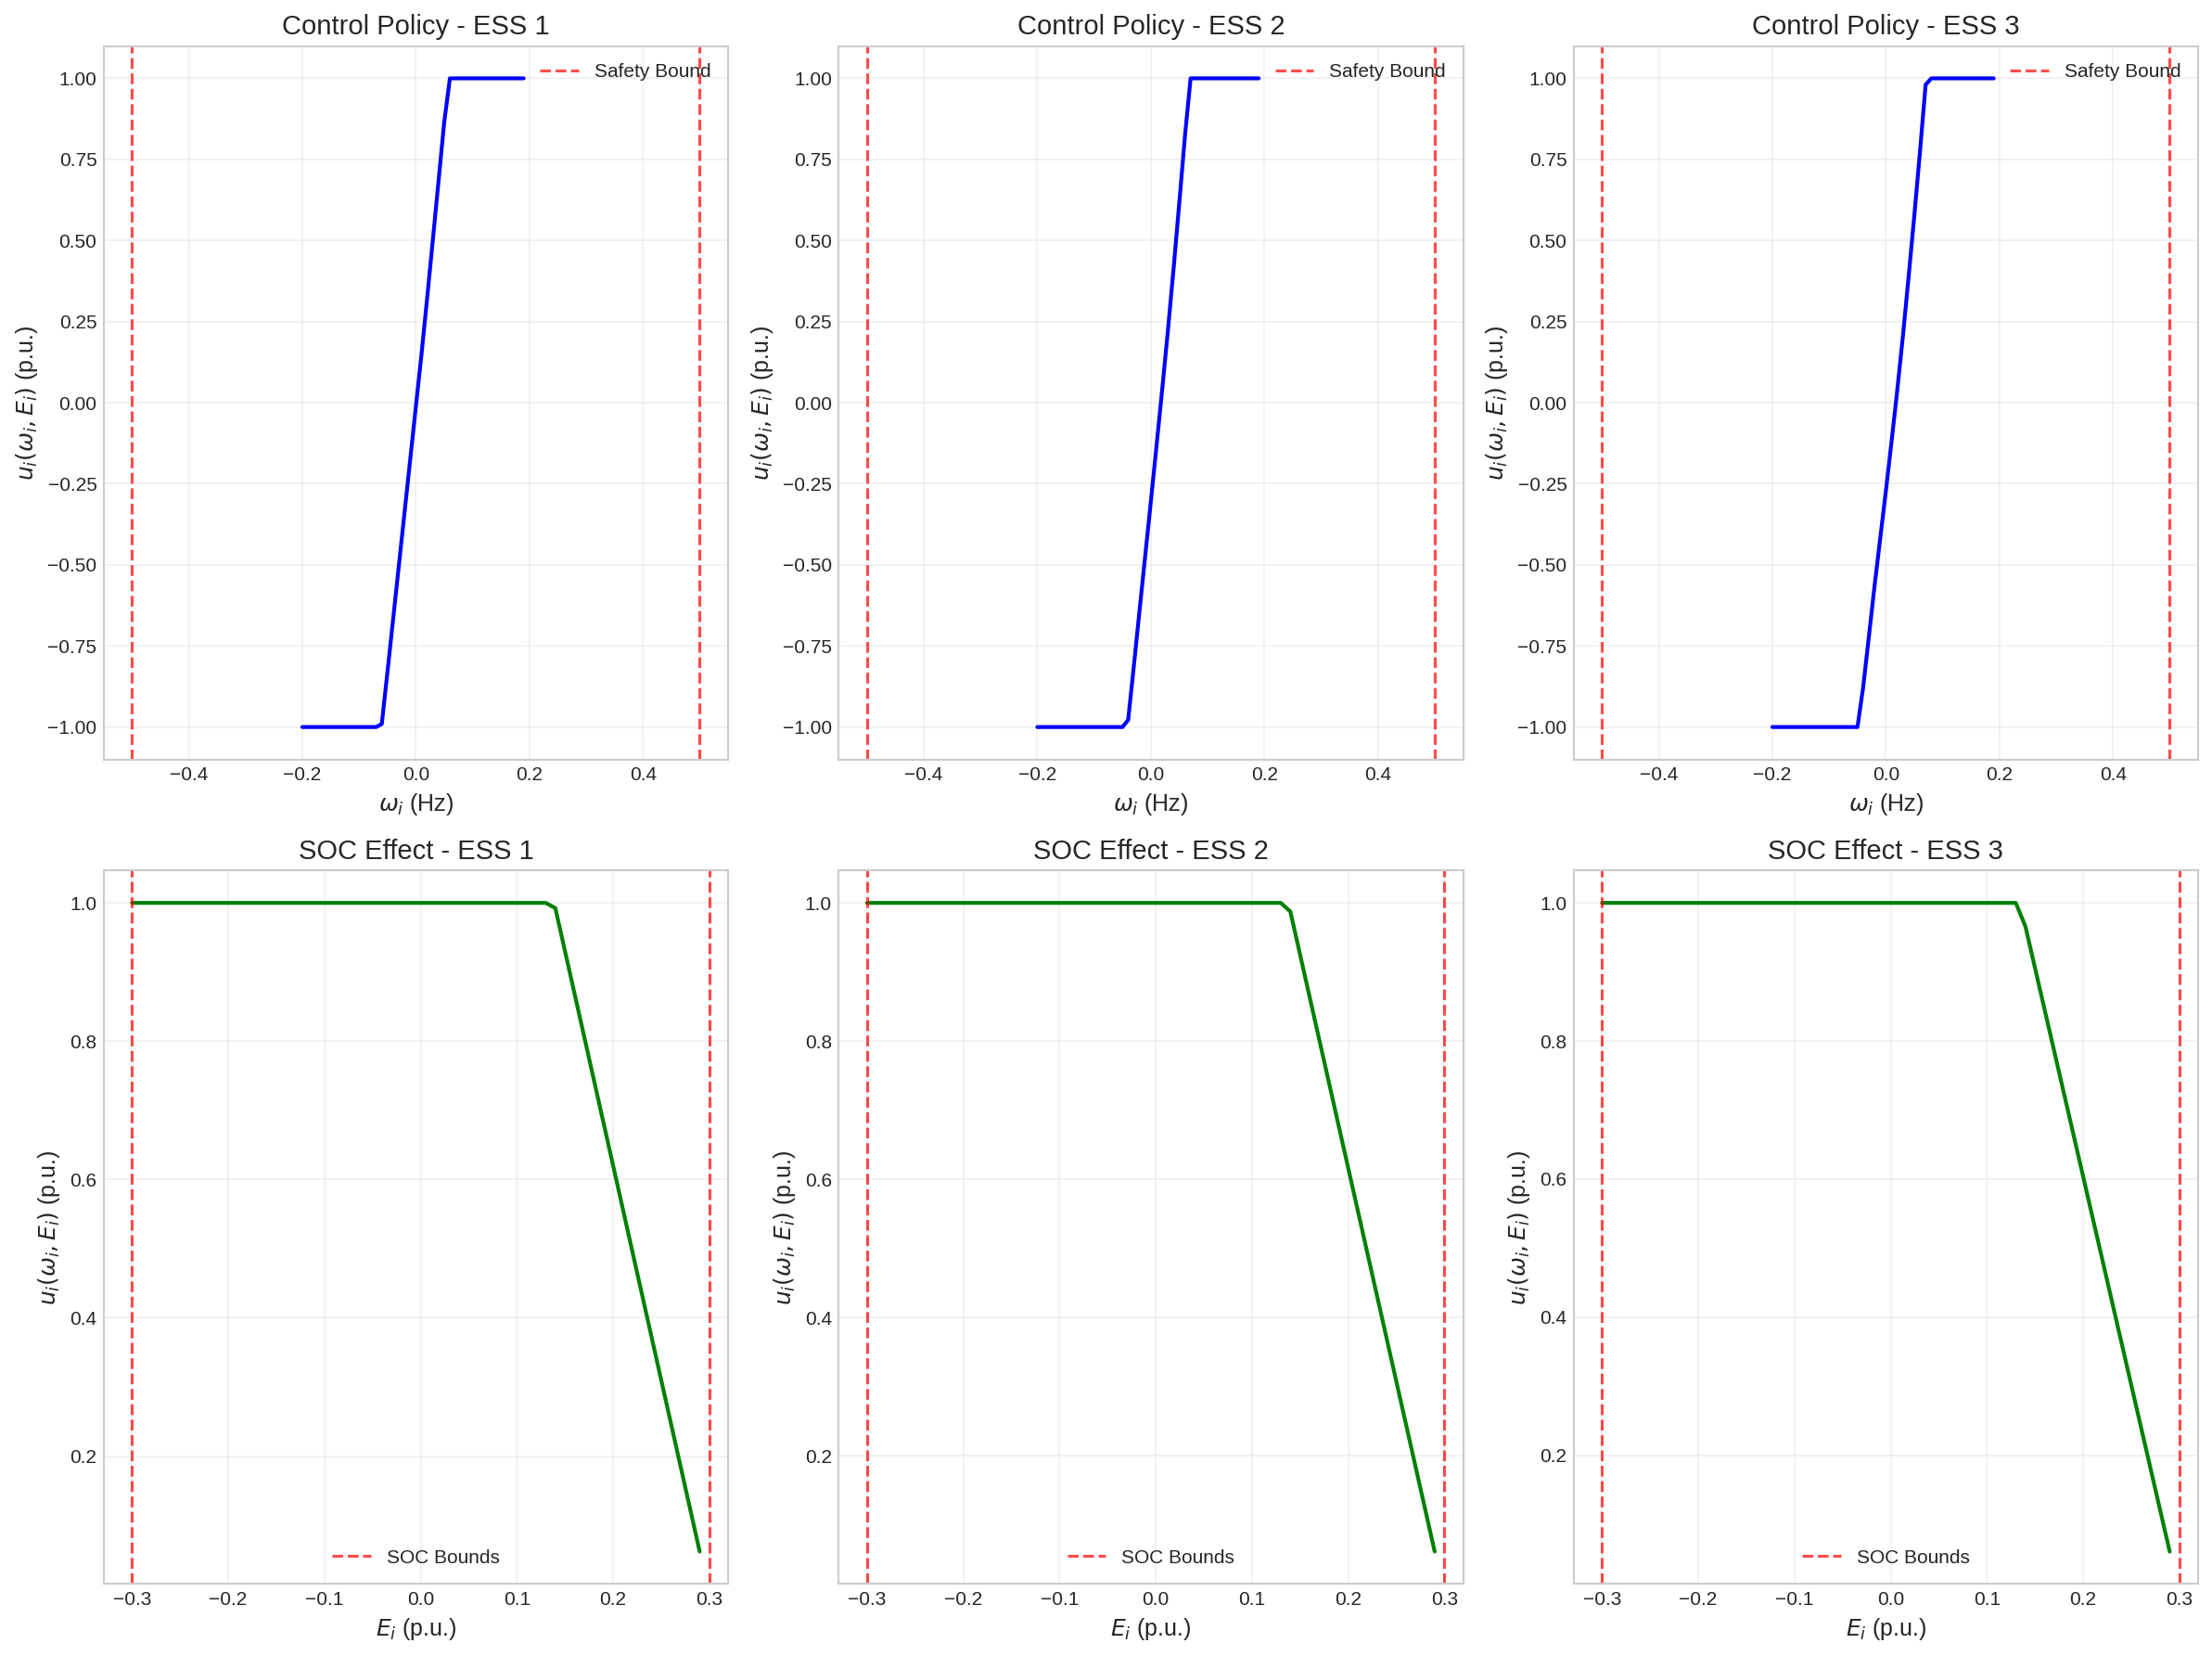

Visualization completed!


In [47]:
# 初始化轨迹记录
Trajectory_RNN_omega = []
Trajectory_RNN_omega_true = []
Trajectory_RNN_theta = []
Trajectory_RNN_Pm = []
Trajectory_RNN_Pg = []
Trajectory_RNN_E = []
Trajectory_Safety_Info = []  # 新增：安全信息记录

# 设置初始状态
theta_rnn_init_bound = 0.05
omega_rnn_init_bound = 0.1  # in Hz
Pm_rnn_init_bound = 0.5
Pg_rnn_init_bound = 0.1
E_rnn_init_bound = 0.3  # E_upper

s_concate = np.zeros((1, 5 * dim_state))

initial_state1 = np.random.uniform(-theta_rnn_init_bound, theta_rnn_init_bound, (1, dim_state))
initial_state2 = np.random.uniform(-omega_rnn_init_bound, omega_rnn_init_bound, (1, dim_state))
initial_state3 = np.random.uniform(-Pm_rnn_init_bound, Pm_rnn_init_bound, (1, dim_state))
initial_state4 = np.random.uniform(-Pg_rnn_init_bound, Pg_rnn_init_bound, (1, dim_state))
initial_state5 = np.random.uniform(-E_rnn_init_bound, E_rnn_init_bound, (1, dim_state))
s_concate = np.hstack((initial_state1, initial_state2, initial_state3, initial_state4, initial_state5)).astype(np.float64)

# 设置负载变化测试
Pl_change_test = np.zeros((1, dim_state), dtype=np.float64)
# 可以选择特定的发电机节点进行扰动测试
generator_loss_node = 0  # 选择第一个发电机
Pl_change_test[0, generator_loss_node] = 0.5  # 0.5 p.u. 的负载增加

init_state = s_concate + equilibrium_init

s = init_state
s_record_all_omega = s @ env.select_omega
s_record_all_theta = s @ env.select_theta
s_record_all_Pm = s @ env.select_Pm
s_record_all_Pg = s @ env.select_Pg
s_record_all_E = s @ env.select_E
s_record_all_omega_true = s_record_all_omega + 60 * np.ones((1, dim_state))

env.set_state(s)
Trajectory_RNN_omega.append(s_record_all_omega)
Trajectory_RNN_theta.append(s_record_all_theta)
Trajectory_RNN_omega_true.append(s_record_all_omega_true)
Trajectory_RNN_Pm.append(s_record_all_Pm)
Trajectory_RNN_Pg.append(s_record_all_Pg)
Trajectory_RNN_E.append(s_record_all_E)

Test_time = 20
SimulationLength = int(Test_time / delta_t)
Record_u_RNN = []
Record_e_RNN = []
Record_safety_info = []  # 记录安全信息

print("Starting integrated controller simulation...")
for i in range(SimulationLength):
    # 使用集成控制器
    e, u, safety_info = Action_Integrated(s, env)
    next_s = env.step(u, Pl_change_test)
    s = next_s

    # 记录状态
    s_record_all_omega = s @ env.select_omega
    s_record_all_theta = s @ env.select_theta
    s_record_all_Pm = s @ env.select_Pm
    s_record_all_Pg = s @ env.select_Pg
    s_record_all_E = s @ env.select_E
    s_record_all_omega_true = s_record_all_omega + 60 * np.ones((1, dim_state))

    Trajectory_RNN_omega.append(s_record_all_omega)
    Trajectory_RNN_theta.append(s_record_all_theta)
    Trajectory_RNN_omega_true.append(s_record_all_omega_true)
    Trajectory_RNN_Pm.append(s_record_all_Pm)
    Trajectory_RNN_Pg.append(s_record_all_Pg)
    Trajectory_RNN_E.append(s_record_all_E)
    Record_e_RNN.append(e)
    Record_u_RNN.append(u)
    Record_safety_info.append(safety_info)

    if i % 100 == 0:
        print(f"Simulation progress: {i}/{SimulationLength}")

# 转换为numpy数组
Trajectory_RNN_omega = np.squeeze(np.asarray(Trajectory_RNN_omega))
Trajectory_RNN_theta = np.squeeze(np.asarray(Trajectory_RNN_theta))
Trajectory_RNN_Pm = np.squeeze(np.asarray(Trajectory_RNN_Pm))
Trajectory_RNN_Pg = np.squeeze(np.asarray(Trajectory_RNN_Pg))
Trajectory_RNN_E = np.squeeze(np.asarray(Trajectory_RNN_E))
Trajectory_RNN_omega_true = np.squeeze(np.asarray(Trajectory_RNN_omega_true))
Record_u_RNN = np.squeeze(np.asarray(Record_u_RNN))
Record_e_RNN = np.squeeze(np.asarray(Record_e_RNN))

# ==================== 可视化结果 ====================

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(25, 18), dpi=100)

# 时间轴
TimeRecord_full = np.arange(0, SimulationLength + 1) * env.delta_t
TimeRecord_action = np.arange(0, SimulationLength) * env.delta_t

# 1. 控制动作
plt.subplot(3, 4, 1)
for i in range(dim_state):
    plt.plot(TimeRecord_action, Record_u_RNN[:, i], label=f'Gen {i+1}', linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('ESS Power (p.u.)', fontsize=12)
plt.title('(a) ESS Control Actions', fontsize=14)
plt.legend(fontsize=8, ncol=2)

# 2. 频率响应
plt.subplot(3, 4, 2)
for i in range(dim_state):
    plt.plot(TimeRecord_full, Trajectory_RNN_omega[:, i], label=f'Gen {i+1}', linewidth=1.5)
# 添加频率安全边界
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Safety Upper Bound')
plt.axhline(y=-0.5, color='r', linestyle='--', alpha=0.7, label='Safety Lower Bound')
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Frequency Deviation (Hz)', fontsize=12)
plt.title('(b) Frequency Response', fontsize=14)
plt.legend(fontsize=8)

# 3. 相角
plt.subplot(3, 4, 3)
for i in range(dim_state):
    plt.plot(TimeRecord_full, Trajectory_RNN_theta[:, i], label=f'Gen {i+1}', linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Phase Angle (rad)', fontsize=12)
plt.title('(c) Phase Angles', fontsize=14)
plt.legend(fontsize=8)

# 4. 机械功率
plt.subplot(3, 4, 4)
for i in range(dim_state):
    plt.plot(TimeRecord_full, Trajectory_RNN_Pm[:, i], label=f'Gen {i+1}', linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Mechanical Power (p.u.)', fontsize=12)
plt.title('(d) Mechanical Power', fontsize=14)
plt.legend(fontsize=8)

# 5. 发电机功率
plt.subplot(3, 4, 5)
for i in range(dim_state):
    plt.plot(TimeRecord_full, Trajectory_RNN_Pg[:, i], label=f'Gen {i+1}', linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Generator Power (p.u.)', fontsize=12)
plt.title('(e) Generator Power', fontsize=14)
plt.legend(fontsize=8)

# 6. ESS SOC
plt.subplot(3, 4, 6)
for i in range(dim_state):
    plt.plot(TimeRecord_full, Trajectory_RNN_E[:, i], label=f'ESS {i+1}', linewidth=1.5)
# 添加SOC安全边界
plt.axhline(y=0.3, color='r', linestyle='--', alpha=0.7, label='SOC Upper Bound')
plt.axhline(y=-0.3, color='r', linestyle='--', alpha=0.7, label='SOC Lower Bound')
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('ESS State of Charge (p.u.)', fontsize=12)
plt.title('(f) ESS State of Charge', fontsize=14)
plt.legend(fontsize=8)

# 7. 频率安全分析
plt.subplot(3, 4, 7)
max_freq_deviation = np.max(np.abs(Trajectory_RNN_omega), axis=1)
plt.plot(TimeRecord_full, max_freq_deviation, 'b-', linewidth=2, label='Max Frequency Deviation')
plt.axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='Safety Limit')
plt.fill_between(TimeRecord_full, max_freq_deviation, 0.5,
                 where=(max_freq_deviation > 0.5), color='red', alpha=0.3, label='Safety Violation')
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Frequency Deviation (Hz)', fontsize=12)
plt.title('(g) Frequency Safety Analysis', fontsize=14)
plt.legend(fontsize=10)

# 8. SOC安全分析
plt.subplot(3, 4, 8)
max_soc = np.max(Trajectory_RNN_E, axis=1)
min_soc = np.min(Trajectory_RNN_E, axis=1)
plt.plot(TimeRecord_full, max_soc, 'g-', linewidth=2, label='Max SOC')
plt.plot(TimeRecord_full, min_soc, 'b-', linewidth=2, label='Min SOC')
plt.axhline(y=0.3, color='r', linestyle='--', linewidth=2, label='SOC Upper Bound')
plt.axhline(y=-0.3, color='r', linestyle='--', linewidth=2, label='SOC Lower Bound')
plt.fill_between(TimeRecord_full, max_soc, 0.3,
                 where=(max_soc > 0.3), color='red', alpha=0.3, label='Upper Violation')
plt.fill_between(TimeRecord_full, min_soc, -0.3,
                 where=(min_soc < -0.3), color='red', alpha=0.3, label='Lower Violation')
plt.grid(True, alpha=0.3)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('SOC (p.u.)', fontsize=12)
plt.title('(h) SOC Safety Analysis', fontsize=14)
plt.legend(fontsize=10)

# 9. 控制动作分解（第一个ESS）
plt.subplot(3, 4, 9)
if len(Record_safety_info) > 0:
    ess_idx = 0  # 查看第一个ESS

    # 安全地提取数据，处理可能的形状问题
    base_actions = []
    freq_safe_actions = []
    final_actions = []

    for info in Record_safety_info:
        # 处理 base_action
        if 'base_action' in info and info['base_action'] is not None:
            base_action_data = info['base_action']
            if base_action_data.ndim == 2 and base_action_data.shape[0] > 0 and base_action_data.shape[1] > ess_idx:
                base_actions.append(base_action_data[0][ess_idx])
            elif base_action_data.ndim == 1 and base_action_data.shape[0] > ess_idx:
                base_actions.append(base_action_data[ess_idx])
            else:
                base_actions.append(0.0)  # 默认值
        else:
            base_actions.append(0.0)  # 默认值

        # 处理 frequency_safe_action
        if 'frequency_safe_action' in info and info['frequency_safe_action'] is not None:
            freq_action_data = info['frequency_safe_action']
            if freq_action_data.ndim == 2 and freq_action_data.shape[0] > 0 and freq_action_data.shape[1] > ess_idx:
                freq_safe_actions.append(freq_action_data[0][ess_idx])
            elif freq_action_data.ndim == 1 and freq_action_data.shape[0] > ess_idx:
                freq_safe_actions.append(freq_action_data[ess_idx])
            else:
                freq_safe_actions.append(0.0)  # 默认值
        else:
            freq_safe_actions.append(0.0)  # 默认值

        # 处理 final_action
        if 'final_action' in info and info['final_action'] is not None:
            final_action_data = info['final_action']
            if final_action_data.ndim == 2 and final_action_data.shape[0] > 0 and final_action_data.shape[1] > ess_idx:
                final_actions.append(final_action_data[0][ess_idx])
            elif final_action_data.ndim == 1 and final_action_data.shape[0] > ess_idx:
                final_actions.append(final_action_data[ess_idx])
            else:
                final_actions.append(0.0)  # 默认值
        else:
            final_actions.append(0.0)  # 默认值

    plt.plot(TimeRecord_action, base_actions, 'b-', linewidth=2, label='Base Action')
    plt.plot(TimeRecord_action, freq_safe_actions, 'g-', linewidth=2, label='Frequency Safe Action')
    plt.plot(TimeRecord_action, final_actions, 'r-', linewidth=2, label='Final Action (with SOC Filter)')
    plt.grid(True, alpha=0.3)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Control Action (p.u.)', fontsize=12)
    plt.title('(i) Control Action Decomposition (ESS 1)', fontsize=14)
    plt.legend(fontsize=10)

# 10. 安全屏障效果（第一个ESS）
plt.subplot(3, 4, 10)
if len(Record_safety_info) > 0:
    ess_idx = 0

    # 安全地提取数据
    states_E = []
    upper_barriers = []
    lower_barriers = []

    for info in Record_safety_info:
        # 处理 states_E
        if 'states_E' in info and info['states_E'] is not None:
            states_E_data = info['states_E']
            if states_E_data.ndim == 2 and states_E_data.shape[0] > 0 and states_E_data.shape[1] > ess_idx:
                states_E.append(states_E_data[0][ess_idx])
            elif states_E_data.ndim == 1 and states_E_data.shape[0] > ess_idx:
                states_E.append(states_E_data[ess_idx])
            else:
                states_E.append(0.0)  # 默认值
        else:
            states_E.append(0.0)  # 默认值

        # 处理 upper_barrier
        if 'upper_barrier' in info and info['upper_barrier'] is not None:
            upper_barrier_data = info['upper_barrier']
            if upper_barrier_data.ndim == 2 and upper_barrier_data.shape[0] > 0 and upper_barrier_data.shape[1] > ess_idx:
                upper_barriers.append(upper_barrier_data[0][ess_idx])
            elif upper_barrier_data.ndim == 1 and upper_barrier_data.shape[0] > ess_idx:
                upper_barriers.append(upper_barrier_data[ess_idx])
            else:
                upper_barriers.append(1.0)  # 默认值
        else:
            upper_barriers.append(1.0)  # 默认值

        # 处理 lower_barrier
        if 'lower_barrier' in info and info['lower_barrier'] is not None:
            lower_barrier_data = info['lower_barrier']
            if lower_barrier_data.ndim == 2 and lower_barrier_data.shape[0] > 0 and lower_barrier_data.shape[1] > ess_idx:
                lower_barriers.append(lower_barrier_data[0][ess_idx])
            elif lower_barrier_data.ndim == 1 and lower_barrier_data.shape[0] > ess_idx:
                lower_barriers.append(lower_barrier_data[ess_idx])
            else:
                lower_barriers.append(1.0)  # 默认值
        else:
            lower_barriers.append(1.0)  # 默认值

    # 获取边界值
    boundary_upper = 0.0
    boundary_lower = 0.0
    if len(Record_safety_info) > 0 and 'boundary_upper' in Record_safety_info[0]:
        boundary_data = Record_safety_info[0]['boundary_upper']
        if boundary_data.ndim == 2 and boundary_data.shape[0] > 0 and boundary_data.shape[1] > ess_idx:
            boundary_upper = boundary_data[0][ess_idx]
        elif boundary_data.ndim == 1 and boundary_data.shape[0] > ess_idx:
            boundary_upper = boundary_data[ess_idx]

    if len(Record_safety_info) > 0 and 'boundary_lower' in Record_safety_info[0]:
        boundary_data = Record_safety_info[0]['boundary_lower']
        if boundary_data.ndim == 2 and boundary_data.shape[0] > 0 and boundary_data.shape[1] > ess_idx:
            boundary_lower = boundary_data[0][ess_idx]
        elif boundary_data.ndim == 1 and boundary_data.shape[0] > ess_idx:
            boundary_lower = boundary_data[ess_idx]

    plt.plot(TimeRecord_action, states_E, 'b-', linewidth=2, label='SOC')
    plt.axhline(y=0.3, color='r', linestyle='--', linewidth=2, label='SOC Upper Bound')
    plt.axhline(y=-0.3, color='r', linestyle='--', linewidth=2, label='SOC Lower Bound')
    plt.axhline(y=boundary_upper, color='orange', linestyle=':', linewidth=2, label='Barrier Upper Threshold')
    plt.axhline(y=boundary_lower, color='orange', linestyle=':', linewidth=2, label='Barrier Lower Threshold')
    plt.grid(True, alpha=0.3)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('SOC (p.u.)', fontsize=12)
    plt.title('(j) SOC Safety Barrier (ESS 1)', fontsize=14)
    plt.legend(fontsize=8)

# 11. 性能指标总结
plt.subplot(3, 4, 11)
# 计算性能指标
max_freq_nadir = np.min(Trajectory_RNN_omega)  # 频率最低点
max_freq_peak = np.max(Trajectory_RNN_omega)   # 频率最高点
settling_time_idx = np.where(np.abs(Trajectory_RNN_omega[-100:, :]) < 0.02)[0]  # 稳定时间
# 改进的稳定时间计算
def calculate_settling_time(frequency_trajectory, delta_t, tolerance=0.02):
    """计算稳定时间"""
    # 找到最后一个超过容忍度的时间点
    exceeding_indices = np.where(np.abs(frequency_trajectory) > tolerance)[0]
    if len(exceeding_indices) > 0:
        last_exceed_idx = exceeding_indices[-1]
        settling_time = last_exceed_idx * delta_t
    else:
        settling_time = 0  # 如果一开始就在容忍范围内

    return settling_time

# 对每个发电机计算稳定时间，取最大值
settling_times = []
for i in range(dim_state):
    settling_time_i = calculate_settling_time(Trajectory_RNN_omega[:, i], env.delta_t)
    settling_times.append(settling_time_i)

settling_time = max(settling_times)
total_control_effort = np.sum(np.abs(Record_u_RNN)) * env.delta_t

metrics = ['Max Freq Nadir', 'Max Freq Peak', 'Settling Time', 'Control Effort']
values = [max_freq_nadir, max_freq_peak, settling_time, total_control_effort]
units = ['Hz', 'Hz', 's', 'p.u.·s']

bars = plt.bar(metrics, values, color=['lightcoral', 'lightblue', 'lightgreen', 'lightsalmon'])
plt.ylabel('Value', fontsize=12)
plt.title('(k) Performance Metrics', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# 在柱状图上添加数值标签
for bar, value, unit in zip(bars, values, units):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(values),
             f'{value:.3f} {unit}', ha='center', va='bottom', fontsize=10)

# 12. 安全约束满足情况
plt.subplot(3, 4, 12)
# 计算约束违反情况
freq_upper_violation = np.sum(Trajectory_RNN_omega > 0.5) / Trajectory_RNN_omega.size * 100
freq_lower_violation = np.sum(Trajectory_RNN_omega < -0.5) / Trajectory_RNN_omega.size * 100
soc_upper_violation = np.sum(Trajectory_RNN_E > 0.3) / Trajectory_RNN_E.size * 100
soc_lower_violation = np.sum(Trajectory_RNN_E < -0.3) / Trajectory_RNN_E.size * 100

constraints = ['Freq Upper', 'Freq Lower', 'SOC Upper', 'SOC Lower']
violations = [freq_upper_violation, freq_lower_violation, soc_upper_violation, soc_lower_violation]

bars = plt.bar(constraints, violations, color=['lightcoral', 'lightcoral', 'lightblue', 'lightblue'])
plt.ylabel('Violation Percentage (%)', fontsize=12)
plt.title('(l) Constraint Violations', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

# 在柱状图上添加数值标签
for bar, violation in zip(bars, violations):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{violation:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ==================== 打印性能总结 ====================
print("\n" + "="*60)
print("INTEGRATED CONTROLLER PERFORMANCE SUMMARY")
print("="*60)
print(f"Maximum Frequency Nadir: {max_freq_nadir:.4f} Hz")
print(f"Maximum Frequency Peak: {max_freq_peak:.4f} Hz")
print(f"Settling Time (to ±0.02 Hz): {settling_time:.2f} s")
print(f"Total Control Effort: {total_control_effort:.4f} p.u.·s")
print(f"Frequency Constraint Violations: {freq_upper_violation + freq_lower_violation:.2f}%")
print(f"SOC Constraint Violations: {soc_upper_violation + soc_lower_violation:.2f}%")
print("="*60)

# ==================== 控制策略可视化 ====================
# 绘制控制策略函数
print("\nVisualizing control policy...")
state_w = np.arange(-0.2, 0.2, 0.01, dtype=np.float64)
state_E = np.array([0.0])  # 中间SOC状态

action_dw = np.zeros(len(state_w))
fig = plt.figure(figsize=(16, 12), dpi=150)

for ess_idx in range(min(3, dim_state)):  # 只显示前3个ESS
    for j in range(len(state_w)):
        # 创建测试状态
        state_controlled = np.hstack((
            np.zeros((1, dim_state)),  # theta
            state_w[j] * np.ones((1, dim_state)),  # omega
            np.zeros((1, dim_state)),  # Pm
            np.zeros((1, dim_state)),  # Pg
            state_E * np.ones((1, dim_state))  # E
        ))

        e, u, _ = Action_Integrated(state_controlled, env)
        action_dw[j] = u[0][ess_idx]

    plt.subplot(2, 3, ess_idx + 1)
    plt.plot(state_w, action_dw, 'b-', linewidth=2)
    plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='Safety Bound')
    plt.axvline(x=-0.5, color='r', linestyle='--', alpha=0.7)
    plt.xlabel(r'$\omega_i$ (Hz)', fontsize=12)
    plt.ylabel(r'$u_i(\omega_i, E_i)$ (p.u.)', fontsize=12)
    plt.title(f'Control Policy - ESS {ess_idx + 1}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()

# 绘制SOC对控制策略的影响
state_w_fixed = np.array([0.1])  # 固定频率偏差
state_E_range = np.arange(-0.3, 0.3, 0.01, dtype=np.float64)

action_de = np.zeros(len(state_E_range))
for ess_idx in range(min(3, dim_state)):
    for j in range(len(state_E_range)):
        state_controlled = np.hstack((
            np.zeros((1, dim_state)),
            state_w_fixed * np.ones((1, dim_state)),
            np.zeros((1, dim_state)),
            np.zeros((1, dim_state)),
            state_E_range[j] * np.ones((1, dim_state))
        ))

        e, u, _ = Action_Integrated(state_controlled, env)
        action_de[j] = u[0][ess_idx]

    plt.subplot(2, 3, ess_idx + 4)
    plt.plot(state_E_range, action_de, 'g-', linewidth=2)
    plt.axvline(x=0.3, color='r', linestyle='--', alpha=0.7, label='SOC Bounds')
    plt.axvline(x=-0.3, color='r', linestyle='--', alpha=0.7)
    plt.xlabel('$E_i$ (p.u.)', fontsize=12)
    plt.ylabel(r'$u_i(\omega_i, E_i)$ (p.u.)', fontsize=12)
    plt.title(f'SOC Effect - ESS {ess_idx + 1}', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

print("Visualization completed!")